In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

In [8]:
# Load cleaned dataset
df = pd.read_csv("../dataset/cleaned_city_day.csv")

# Preview
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,118.0
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,118.0
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,118.0
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,118.0
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,118.0


In [9]:
df = pd.read_csv("../dataset/cleaned_city_day.csv")

In [10]:
print(df.shape)

df.info()

df.describe()

(29531, 12)
<class 'pandas.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   City    29531 non-null  str    
 1   Date    29531 non-null  str    
 2   PM2.5   29531 non-null  float64
 3   PM10    29531 non-null  float64
 4   NO      29531 non-null  float64
 5   NO2     29531 non-null  float64
 6   NOx     29531 non-null  float64
 7   NH3     29531 non-null  float64
 8   CO      29531 non-null  float64
 9   SO2     29531 non-null  float64
 10  O3      29531 non-null  float64
 11  AQI     29531 non-null  float64
dtypes: float64(10), str(2)
memory usage: 2.7 MB


,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
count,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000,29531.000000
mean,64.510857,109.659366,16.642601,27.726576,31.063568,20.813789,2.153872,13.830897,33.994121,158.781552
std,59.807551,72.324020,21.506064,23.050531,29.477748,21.028862,6.724660,17.005647,20.202304,130.272413
min,0.040000,0.010000,0.020000,0.010000,0.000000,0.010000,0.000000,0.010000,0.010000,13.000000
25%,32.150000,79.315000,6.210000,12.980000,14.670000,12.040000,0.540000,6.090000,20.740000,88.000000
50%,48.570000,95.680000,9.890000,21.690000,23.520000,15.850000,0.890000,9.160000,30.840000,118.000000
75%,72.450000,111.880000,17.570000,34.665000,36.015000,21.755000,1.380000,13.810000,42.730000,179.000000
max,949.990000,1000.000000,390.680000,362.210000,467.630000,352.890000,175.810000,193.860000,257.730000,2049.000000


In [11]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(["City", "Date"])

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,118.0
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,118.0
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,118.0
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,118.0
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,118.0


In [12]:
scaler = MinMaxScaler()

df["AQI_scaled"] = scaler.fit_transform(df[["AQI"]])

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_scaled
0,Ahmedabad,2015-01-01,48.57,95.68,0.92,18.22,17.15,15.85,0.92,27.64,133.36,118.0,0.051572
1,Ahmedabad,2015-01-02,48.57,95.68,0.97,15.69,16.46,15.85,0.97,24.55,34.06,118.0,0.051572
2,Ahmedabad,2015-01-03,48.57,95.68,17.40,19.30,29.70,15.85,17.40,29.07,30.70,118.0,0.051572
3,Ahmedabad,2015-01-04,48.57,95.68,1.70,18.48,17.97,15.85,1.70,18.59,36.08,118.0,0.051572
4,Ahmedabad,2015-01-05,48.57,95.68,22.10,21.42,37.76,15.85,22.10,39.33,39.31,118.0,0.051572


In [13]:
TIME_STEPS = 30

FORECAST_DAYS = 3

In [14]:
X = []
y = []

cities = df["City"].unique()

for city in cities:

    city_df = df[df["City"] == city].copy()

    city_df = city_df.sort_values("Date")

    values = city_df["AQI_scaled"].values

    if len(values) < TIME_STEPS + FORECAST_DAYS:
        continue

    for i in range(len(values) - TIME_STEPS - FORECAST_DAYS + 1):

        X.append(values[i:i+TIME_STEPS])

        y.append(values[i+TIME_STEPS:i+TIME_STEPS+FORECAST_DAYS])

In [15]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(28699, 30)
(28699, 3)


In [16]:
X = X.reshape((X.shape[0], X.shape[1], 1))

print(X.shape)

(28699, 30, 1)


In [17]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(22959, 30, 1)
(5740, 30, 1)


In [18]:
model = Sequential([
    
    LSTM(
        units=64,
        return_sequences=True,
        input_shape=(TIME_STEPS, 1)
    ),

    Dropout(0.2),

    LSTM(
        units=32
    ),

    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(FORECAST_DAYS)
])

model.summary()

c:\Users\jayan\Air_Intel\ml\ml_env\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,891 (116.76 KB)

 Trainable params: 29,891 (116.76 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [21]:
history = model.fit(
    X_train,
    y_train,

    validation_data=(X_test, y_test),

    epochs=30,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)

Epoch 1/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - loss: 0.0020 - mae: 0.0240 - val_loss: 6.4404e-04 - val_mae: 0.0165
Epoch 2/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0018 - mae: 0.0223 - val_loss: 6.0068e-04 - val_mae: 0.0157
Epoch 3/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - loss: 0.0016 - mae: 0.0214 - val_loss: 5.5485e-04 - val_mae: 0.0151
Epoch 4/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0016 - mae: 0.0212 - val_loss: 5.3216e-04 - val_mae: 0.0146
Epoch 5/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0016 - mae: 0.0208 - val_loss: 5.3818e-04 - val_mae: 0.0148
Epoch 6/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0016 - mae: 0.0205 - val_loss: 5.8157e-04 - val_mae: 0.0148
Epoch 7/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step - loss: 0.0016 - mae: 0.0205 - val_loss: 5.8121e-04 - val_mae: 0.0173
Epoch 8/30
718/718 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - loss: 0.0016 - mae: 0.0204 - val_loss: 5.4618e-04 - val_mae: 0.0151
Epoch 9/

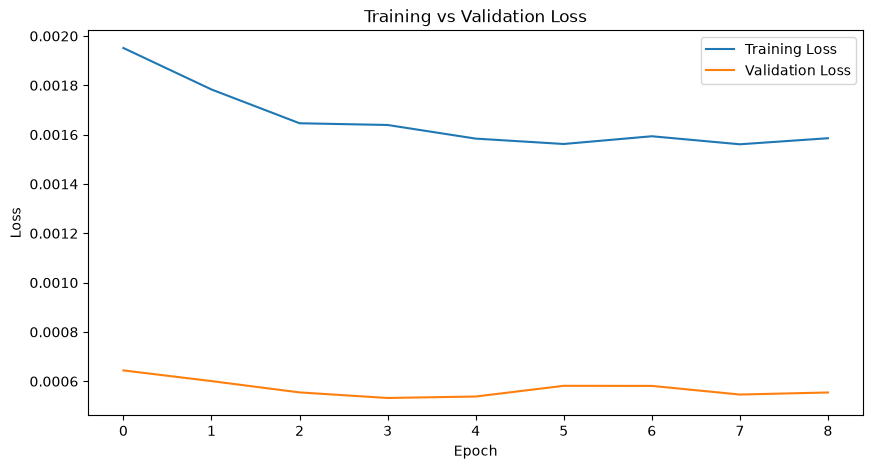

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.show()

In [23]:
predictions = model.predict(X_test)

print(predictions.shape)

180/180 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
(5740, 3)


In [24]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 0.014623181837576422


In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 0.023068669998128823


In [26]:
pred_inv = scaler.inverse_transform(predictions)

actual_inv = scaler.inverse_transform(y_test)

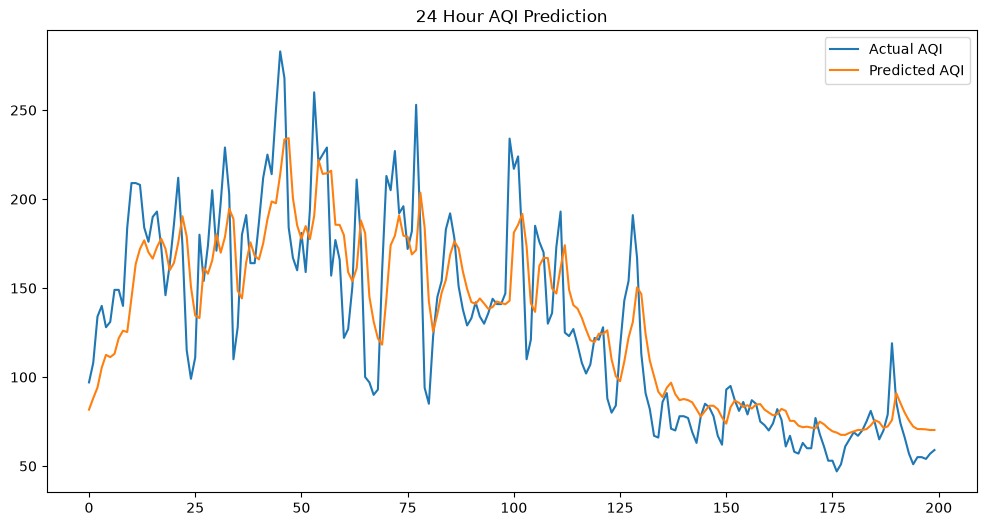

In [27]:
plt.figure(figsize=(12,6))

plt.plot(actual_inv[:200,0], label="Actual AQI")

plt.plot(pred_inv[:200,0], label="Predicted AQI")

plt.legend()

plt.title("24 Hour AQI Prediction")

plt.show()

In [28]:
model.save("../models/lstm_model.keras")

In [29]:
joblib.dump(scaler, "../models/lstm_scaler.pkl")

['../models/lstm_scaler.pkl']

In [30]:
import os

print(os.listdir("../models"))

['lstm_model.keras', 'lstm_scaler.pkl']
